<a href="https://colab.research.google.com/github/karthikaarun374/ICT_DSA/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Developing a machine learning model to predict customer churn for a telecommunications company. The company wants to identify which customers are likely to leave (churn) and target them with retention offers. Your goal is to create a machine learning model that accurately predicts customer churn based on historical customer data.



# Step 1: Understand the Dataset and Load the Data

## Import Libraries

In [129]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

## Load the Dataset

In [130]:
train_df = pd.read_csv("/content/Training_data (1).csv")
test_df = pd.read_csv("/content/Testing_data (2).csv")

## View First 5 rows

In [131]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [132]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


## Check Dataset Shape

In [133]:
train_df.shape

(5634, 21)

In [134]:
test_df.shape

(1409, 21)

# Check Column Names

In [135]:
train_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Check Data Types

In [136]:
train_df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


# Basic Statistical Summary

In [137]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


For Categorical columns

In [138]:
train_df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,5634,5465,5634,5634,5634,5634,5634,5465,5634,5634,5634,5634,5634,5634,5634,5634,5353,5634
unique,5634,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,5040,2
top,3402-XRIUO,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,2744,2890,3960,5081,2701,2486,2720,2459,2485,2782,2244,2232,3094,3350,1892,9,4130


# Step 2: Exploratory Data Analysis (EDA)

## Check Missing Values

In [139]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [140]:
missing_percentage = (train_df.isnull().sum()/len(train_df))*100
missing_percentage.sort_values(ascending = False)

,0
MonthlyCharges,6.993255
TotalCharges,4.987575
OnlineSecurity,2.999645
gender,2.999645
customerID,0.000000
Dependents,0.000000
Partner,0.000000
SeniorCitizen,0.000000
tenure,0.000000
InternetService,0.000000


# Check Blank Spaces in TotalCharges

In [141]:
(train_df['TotalCharges'] == '').sum()

np.int64(0)

In [142]:
train_df['TotalCharges'] = pd.to_numeric(
    train_df['TotalCharges'],
    errors='coerce'
)

In [143]:
train_df['TotalCharges'].dtype

dtype('float64')

# Separate Numerical and Categorical Columns

In [144]:
numerical_cols = train_df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = train_df.select_dtypes(
    include=['object']
).columns

In [145]:
print('Numerical Columns:')
print(numerical_cols)

print("/nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
/nCategorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


# Target Variable Distribution

In [146]:
# Check class distribution:
train_df['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1504


In [147]:
# Percentage:
train_df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.304934
Yes,26.695066


# Visualize Churn Distribution

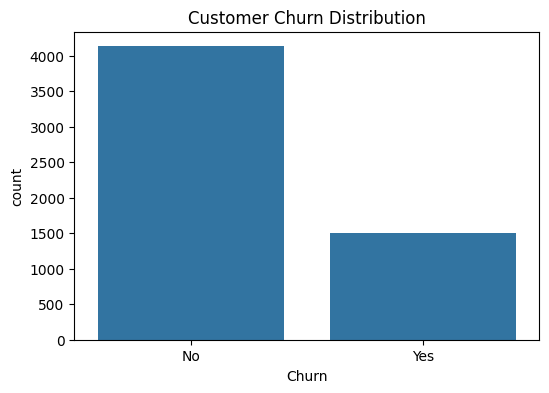

In [148]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=train_df
)

plt.title("Customer Churn Distribution")
plt.show()

# Numerical Feature Distribution

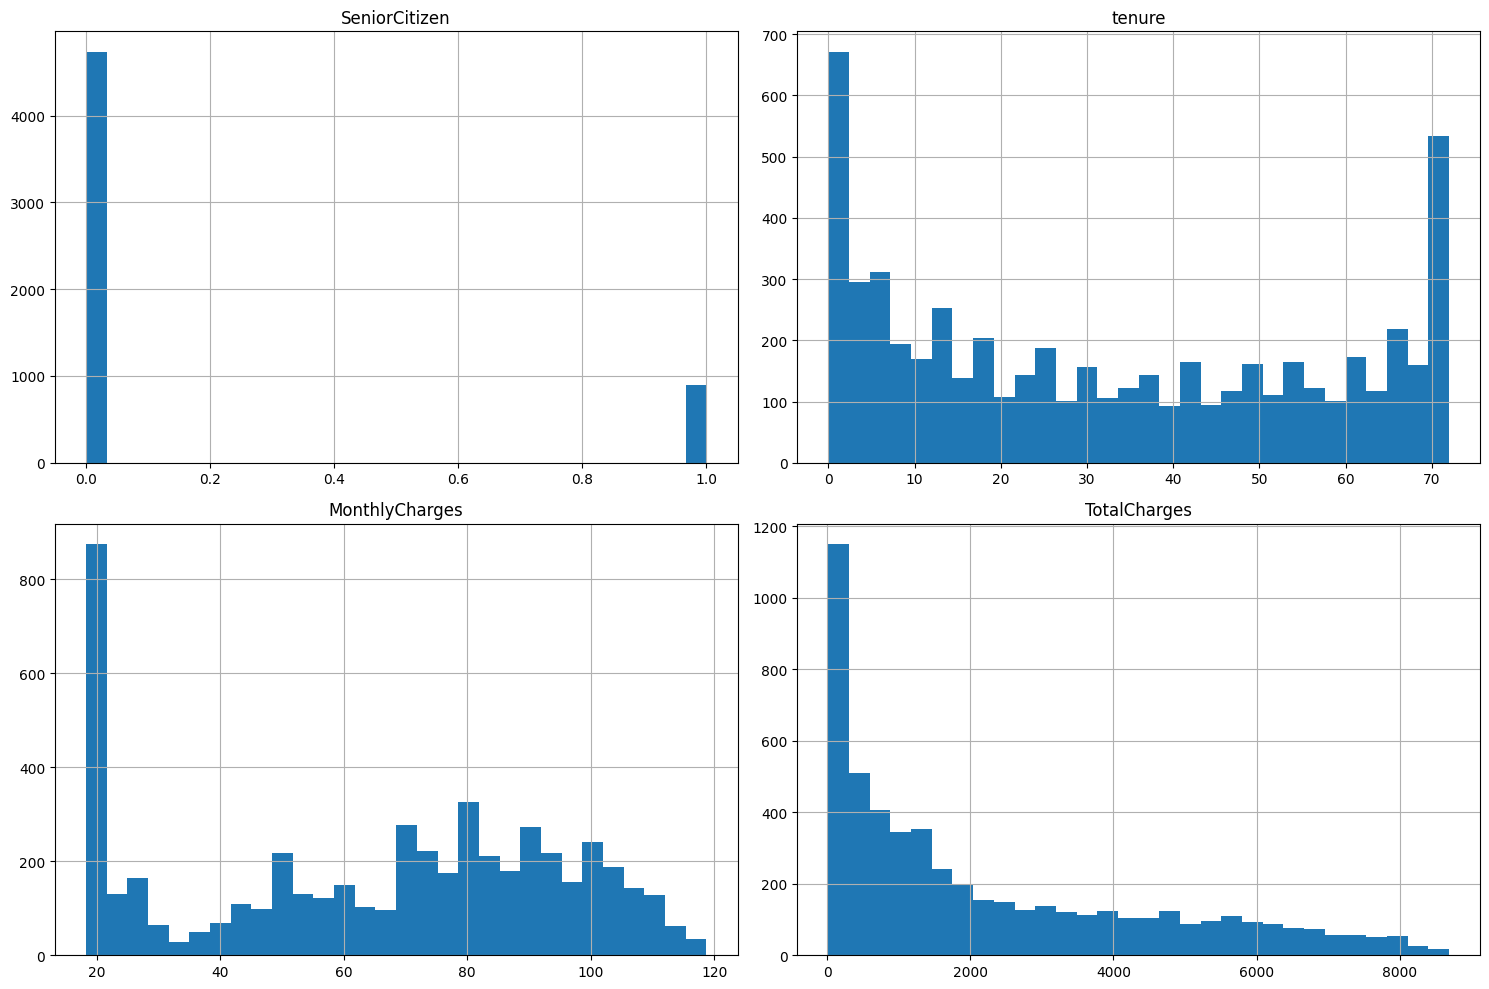

In [149]:
train_df[numerical_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

# Boxplots for Outlier Detection


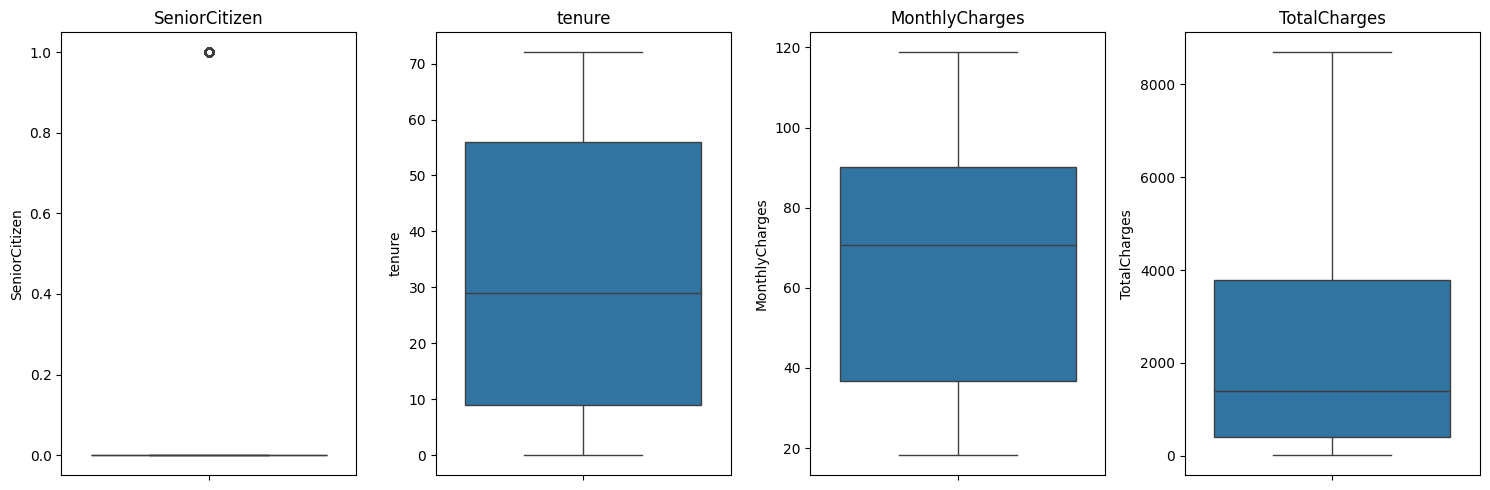

In [150]:
plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_cols, 1):

  plt.subplot(1, len(numerical_cols), i)

  sns.boxplot(
      y=train_df[col]
  )

  plt.title(col)

plt.tight_layout()
plt.show()

# Categorical Feature Analysis

In [151]:
# Countplots for Categorical Features
important_cat_cols = [
    'Contract',
    'PaymentMethod',
    'gender',
    'PaperlessBilling'
]

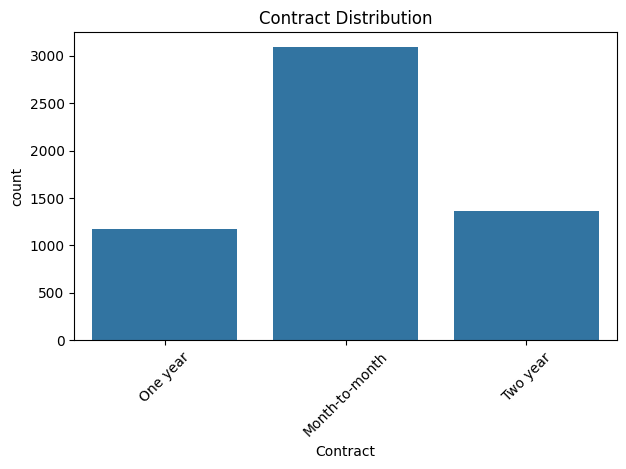

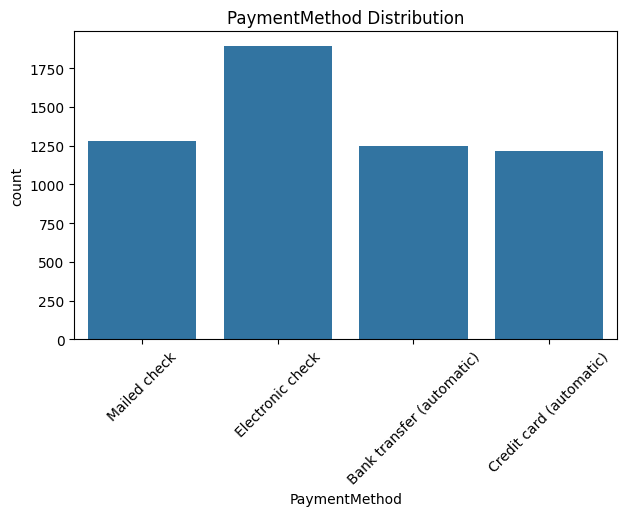

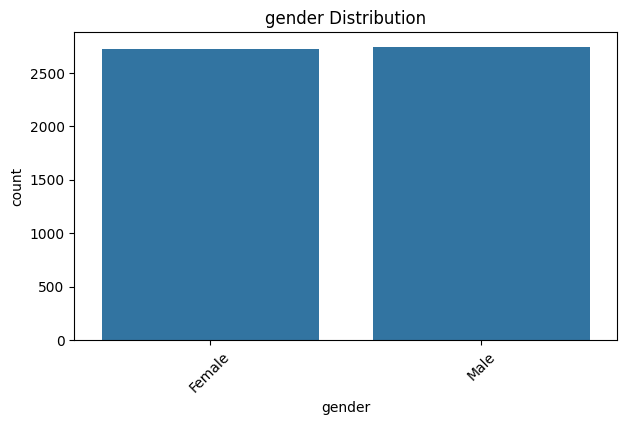

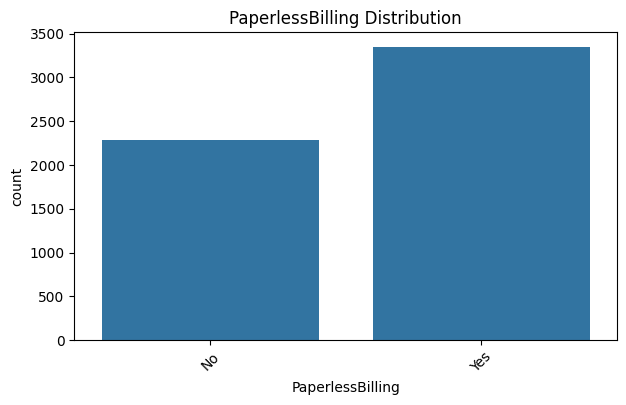

In [152]:
for col in important_cat_cols:

  plt.figure(figsize=(7,4))

  sns.countplot(
      x=col,
      data=train_df
  )

  plt.xticks(rotation=45)

  plt.title(f"{col} Distribution")

  plt.show()

# Relationship Between Features and Churn

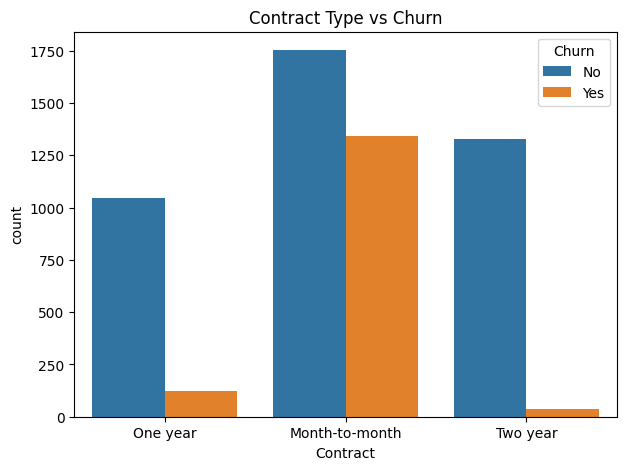

In [153]:
# Churn vs Contract
plt.figure(figsize=(7,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=train_df
)

plt.title("Contract Type vs Churn")

plt.show()

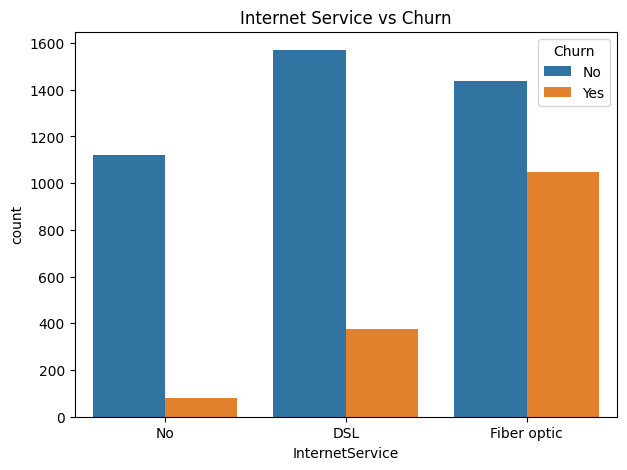

In [154]:
# Churn vs Internet Service
plt.figure(figsize=(7,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=train_df
)

plt.title("Internet Service vs Churn")

plt.show()

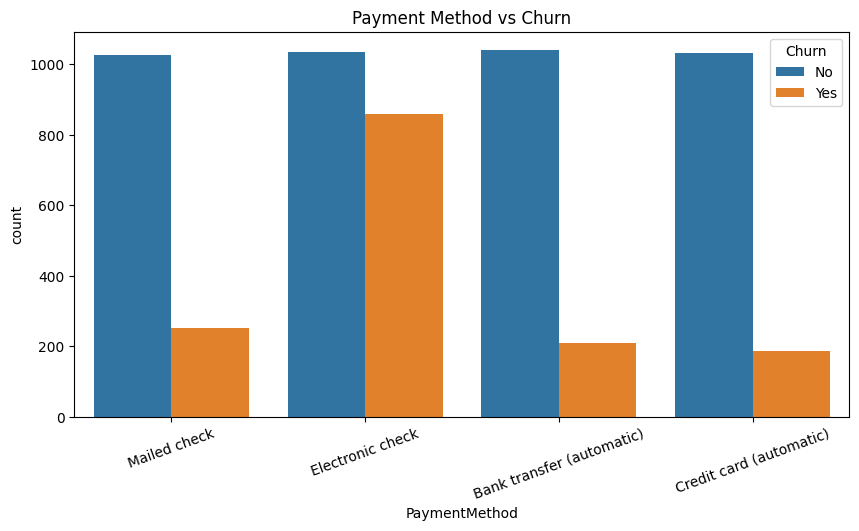

In [155]:
# Churn vs Payment Method
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=train_df
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

# Numerical Features vs Churn

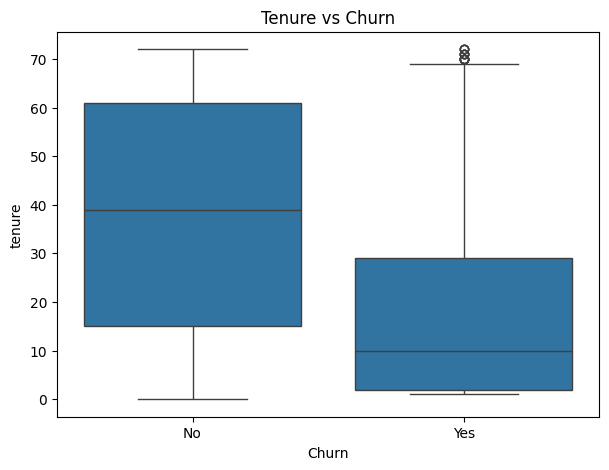

In [156]:
# Tenure vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=train_df
)

plt.title("Tenure vs Churn")

plt.show()

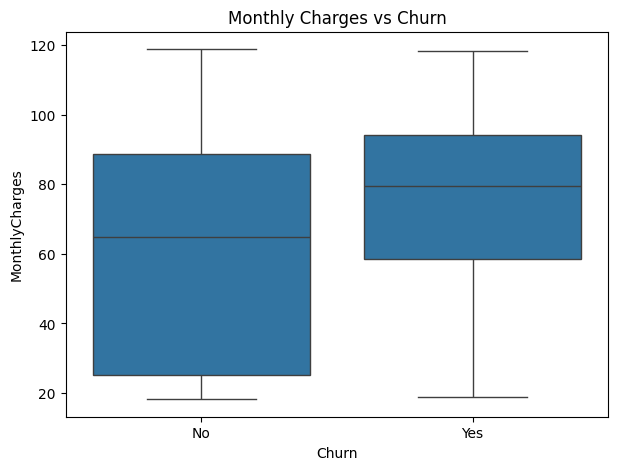

In [157]:
# Monthly Charges vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=train_df
)

plt.title("Monthly Charges vs Churn")

plt.show()

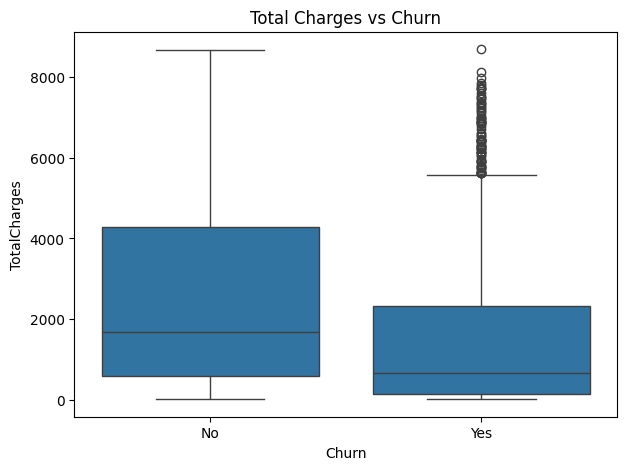

In [158]:
# Total Charges vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=train_df
)

plt.title("Total Charges vs Churn")

plt.show()

## Correlation Analysis

In [159]:
# encode chirn temporarily
train_df['Churn_numeric'] = train_df['Churn'].map({
    'Yes':1,
    'No':0
})

In [160]:
# Correlation Matrix
correlation_matrix = train_df.corr(
    numeric_only=True
)

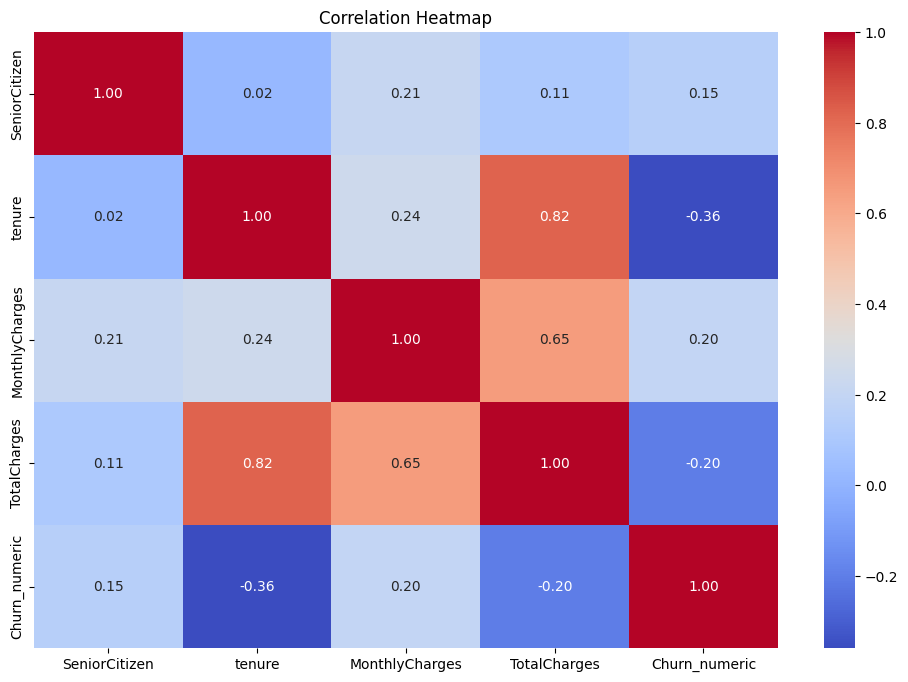

In [161]:
# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

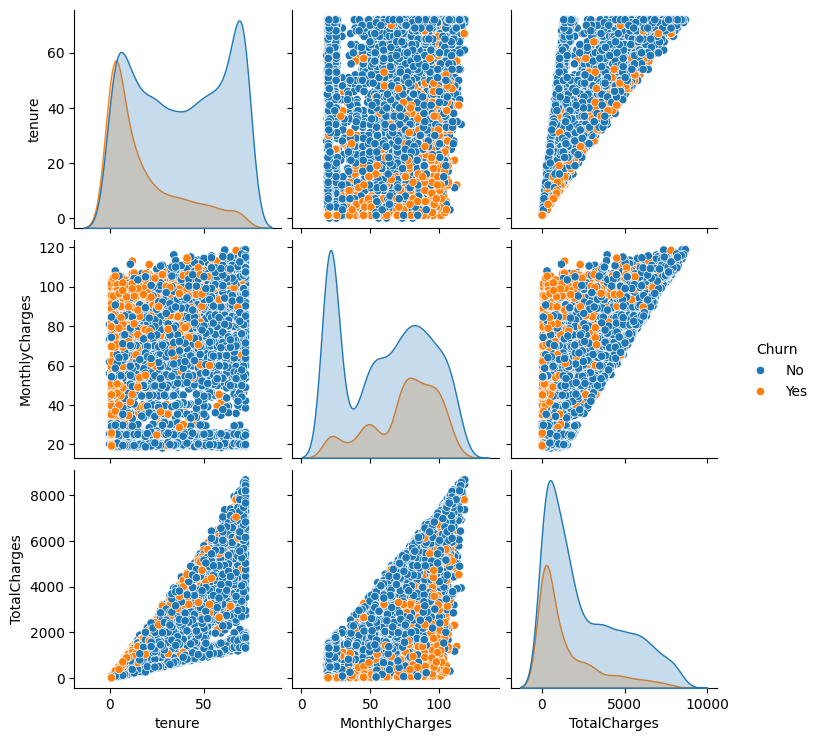

In [162]:
# Pairplot
sns.pairplot(
    train_df[
        [
            'tenure',
            'MonthlyCharges',
            'TotalCharges',
            'Churn'
        ]
    ],
    hue='Churn'
)

plt.show()

# Step 3: Data Preprocessing

### Create a Copy of Dataset

In [163]:
df = train_df.copy()

## Remove Unnecessary Columns

In [164]:
df.drop('customerID', axis=1, inplace=True)

# Handle Missing Values

In [165]:
df.isnull().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [166]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(
    df['MonthlyCharges'].median()
)
df['gender'].fillna(
    df['gender'].mode()[0],
    inplace=True
)
df['OnlineSecurity'].fillna(
    df['OnlineSecurity'].mode()[0],
    inplace=True
)

/tmp/ipykernel_517/3033578427.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(
/tmp/ipykernel_517/3033578427.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}

In [167]:
# Verify Missing Values
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## Encode Target Variable

In [168]:
# Encode Churn
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [169]:
# Verify
df['Churn'].head()

,Churn
0,0
1,0
2,0
3,0
4,0


# Identify Categorical Columns

In [170]:
categorical_cols = df.select_dtypes(
    include=['object']
).columns

numerical_cols = df.select_dtypes(
    exclude=['object']
).columns

In [171]:
# View Columns
print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_numeric'],
      dtype='object')


# Encode Categorical Variables

In [172]:
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [173]:
# Check Encoded Dataset
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Churn_numeric,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,35,20.75,700.45,0,0,False,False,False,True,...,True,False,True,False,True,False,False,False,False,True
1,0,28,35.75,961.40,0,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,0,56,98.60,5581.05,0,0,True,False,False,True,...,False,True,False,True,False,False,False,False,True,False
3,0,39,20.45,790.00,0,0,True,True,False,True,...,True,False,True,False,False,True,True,False,False,False
4,0,43,51.25,2151.60,0,0,False,True,True,False,...,False,True,False,False,True,False,True,False,False,False


In [174]:
# Compare Shapes
print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (5634, 21)
Encoded Shape: (5634, 32)


### Separate Features and Target

In [175]:
X = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

In [176]:
# Verify Shapes
print(X.shape)
print(y.shape)

(5634, 31)
(5634,)


# Train-Test Split

In [177]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [178]:
# Verify Split
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4507, 31)
(1127, 31)
(4507,)
(1127,)


# Feature Scaling

In [179]:
# Initialize Scaler
scaler = StandardScaler()

In [180]:
# Scale Features
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Convert Back to DataFrame

In [181]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# Outlier Handling

In [182]:
# Detect Outliers Using IQR
Q1 = df['MonthlyCharges'].quantile(0.25)

Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['MonthlyCharges'] < lower_bound) |
    (df['MonthlyCharges'] > upper_bound)
]

print(outliers.shape)

(0, 21)


# Step 4: Feature Engineering

In [183]:
# Create a Working Copy
X_train_fe = X_train.drop('Churn_numeric', axis=1).copy()
X_test_fe = X_test.drop('Churn_numeric', axis=1).copy()

In [184]:
# Customer Lifetime Value Feature
X_train_fe['CLV'] = (
    X_train_fe['tenure'] *
    X_train_fe['MonthlyCharges']
)

X_test_fe['CLV'] = (
    X_test_fe['tenure'] *
    X_test_fe['MonthlyCharges']
)

In [185]:
# Average Monthly Spend Feature
X_train_fe['AverageSpend'] = (
    X_train_fe['TotalCharges'] /
    (X_train_fe['tenure'] + 1)
)

X_test_fe['AverageSpend'] = (
    X_test_fe['TotalCharges'] /
    (X_test_fe['tenure'] + 1)
)

# Service Count Feature

In [186]:
# Identify Service Columns
service_cols = [
    col for col in X_train_fe.columns
    if (
        'Online' in col or
        'Streaming' in col or
        'TechSupport' in col or
        'DeviceProtection' in col or
        'PhoneService' in col
    )
]

In [187]:
# View Service Columns
print(service_cols)

['PhoneService_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


In [188]:
# Create Total Services Feature
X_train_fe['TotalServices'] = X_train_fe[
    service_cols
].sum(axis=1)

X_test_fe['TotalServices'] = X_test_fe[
    service_cols
].sum(axis=1)

# Contract Risk Feature

In [189]:
X_train_fe['IsMonthlyContract'] = ~(
    X_train_fe['Contract_One year'] |
    X_train_fe['Contract_Two year']
)

X_test_fe['IsMonthlyContract'] = ~(
    X_test_fe['Contract_One year'] |
    X_test_fe['Contract_Two year']
)

# Tenure Group Feature

In [190]:
# Create Tenure Categories
X_train_fe['TenureGroup'] = pd.cut(
    X_train_fe['tenure'],
    bins=[0,12,24,48,72],
    labels=[0,1,2,3]
)

X_test_fe['TenureGroup'] = pd.cut(
    X_test_fe['tenure'],
    bins=[0,12,24,48,72],
    labels=[0,1,2,3]
)

In [191]:
X_train_fe['TenureGroup'] = (
    X_train_fe['TenureGroup']
    .astype(float) # Convert to float to allow NaN values to be treated as floats
    .fillna(0) # Fill NaN with 0 (assuming tenure=0 should be in the first group)
    .astype(int)
)

X_test_fe['TenureGroup'] = (
    X_test_fe['TenureGroup']
    .astype(float)
    .fillna(0)
    .astype(int)
)

# High Charges Indicator

In [192]:
# premium/high-cost customer indicator
# create feature
monthly_charge_threshold = (
    X_train_fe['MonthlyCharges']
    .median()
)

X_train_fe['HighMonthlyCharges'] = (
    X_train_fe['MonthlyCharges']
    > monthly_charge_threshold
).astype(int)

X_test_fe['HighMonthlyCharges'] = (
    X_test_fe['MonthlyCharges']
    > monthly_charge_threshold
).astype(int)

# Senior Citizen + High Charges Interaction

In [193]:
# Create Feature
X_train_fe['SeniorHighCharges'] = (
    X_train_fe['SeniorCitizen'] *
    X_train_fe['HighMonthlyCharges']
)

X_test_fe['SeniorHighCharges'] = (
    X_test_fe['SeniorCitizen'] *
    X_test_fe['HighMonthlyCharges']
)

# Check New Feature Shapes

In [194]:
print(X_train.shape)

print(X_train_fe.shape)

(4507, 31)
(4507, 37)


# Feature Importance Using Random Fores

In [195]:
# Train Temporary Model
rf_temp = RandomForestClassifier(
    random_state=42
)

rf_temp.fit(
    X_train_fe,
    y_train
)

RandomForestClassifier(random_state=42)

In [196]:
# Extract Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Importance': rf_temp.feature_importances_
})

In [197]:
# Sort Importance
feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [198]:
# View Top Features
feature_importance.head(15)

,Feature,Importance
30,CLV,0.108412
3,TotalCharges,0.105581
31,AverageSpend,0.104032
2,MonthlyCharges,0.103993
1,tenure,0.100990
33,IsMonthlyContract,0.071449
32,TotalServices,0.042238
10,InternetService_Fiber optic,0.034326
34,TenureGroup,0.033163
28,PaymentMethod_Electronic check,0.028038


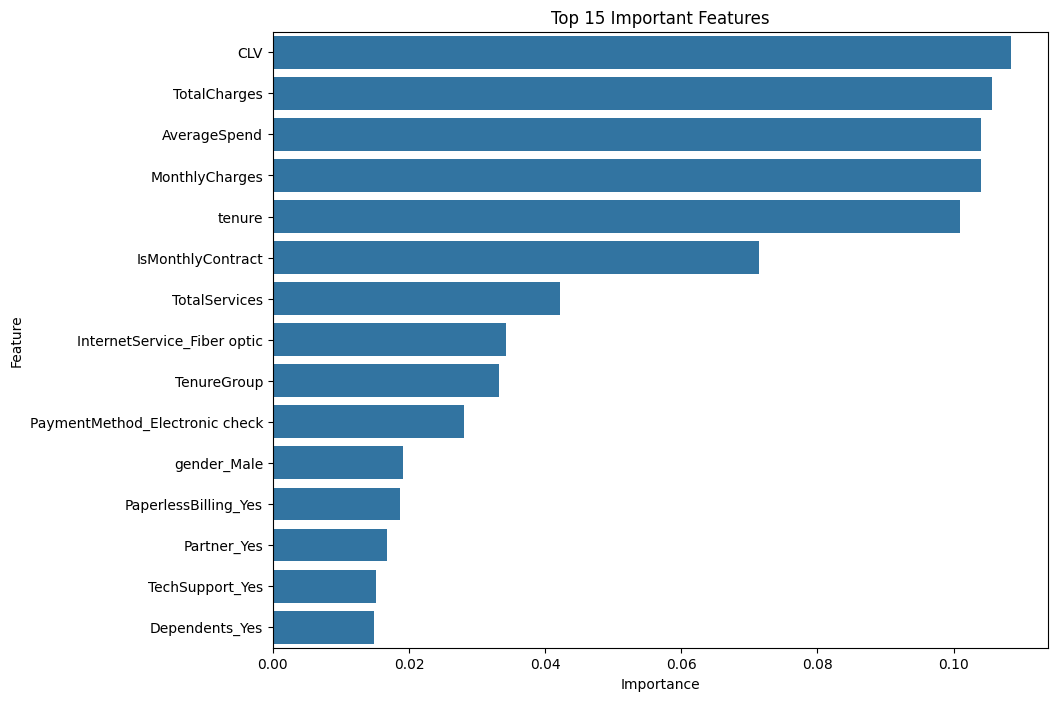

In [199]:
# Visualize Feature Importance
plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

# Remove Low-Importance Features

In [200]:
# Sometimes:

# irrelevant features add noise
# increase overfitting

# You can remove low-importance columns later.

# But for now:

# keep all features

# because tree models handle irrelevant features reasonably well.

# Correlation Between New Features

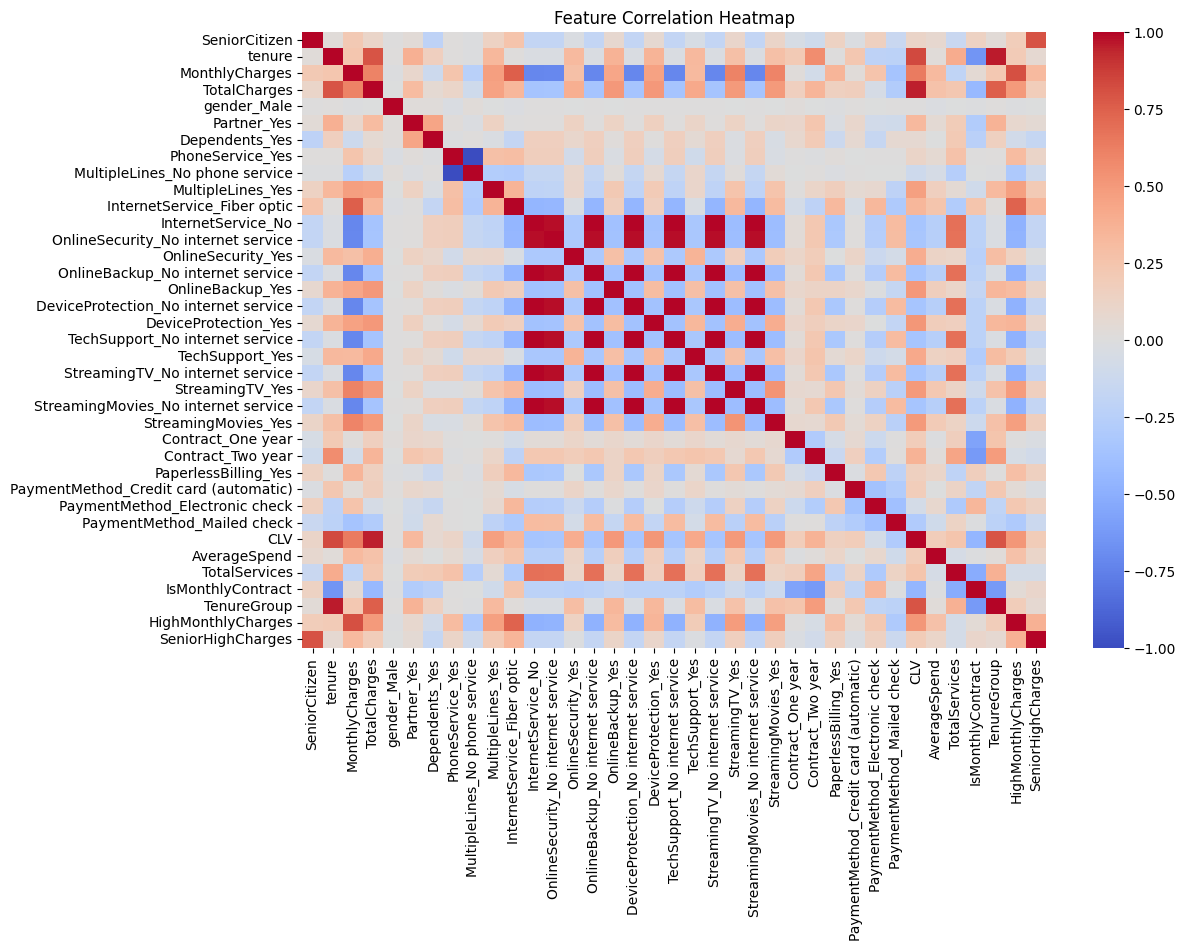

In [201]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X_train_fe.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Step 5: Model Development

In [202]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    try:
        y_prob = model.predict_proba(X_test)[:,1]
    except:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Print results
    print("Accuracy:", accuracy)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1 Score:", f1)

    # ROC-AUC
    if y_prob is not None:

        auc = roc_auc_score(y_test, y_prob)

        print("ROC-AUC:", auc)

    # Confusion Matrix
    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report")

    print(classification_report(y_test, y_pred))

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

# Logistic Regression

In [203]:
# Initialize Model
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  # to handle imbalanced data
)

In [204]:
# Scale feature-engineered data
X_train_fe_scaled = scaler.fit_transform(X_train_fe)
X_test_fe_scaled = scaler.transform(X_test_fe)

X_train_fe_scaled = pd.DataFrame(X_train_fe_scaled, columns=X_train_fe.columns)
X_test_fe_scaled = pd.DataFrame(X_test_fe_scaled, columns=X_test_fe.columns)

# Evaluate
log_results = evaluate_model(
    log_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7506654835847383
Precision: 0.5218340611353712
Recall: 0.7940199335548173
F1 Score: 0.6297760210803689
ROC-AUC: 0.8464078575852888

Confusion Matrix
[[607 219]
 [ 62 239]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       826
           1       0.52      0.79      0.63       301

    accuracy                           0.75      1127
   macro avg       0.71      0.76      0.72      1127
weighted avg       0.80      0.75      0.76      1127



# K-NN

In [205]:
# Initialize Model
knn_model = KNeighborsClassifier(
    n_neighbors=5,
)

In [206]:
# Evaluate
knn_results = evaluate_model(
    knn_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.774622892635315
Precision: 0.5770491803278689
Recall: 0.584717607973422
F1 Score: 0.5808580858085809
ROC-AUC: 0.7889963237955806

Confusion Matrix
[[697 129]
 [125 176]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       826
           1       0.58      0.58      0.58       301

    accuracy                           0.77      1127
   macro avg       0.71      0.71      0.71      1127
weighted avg       0.78      0.77      0.78      1127



# Naive Bayes

In [207]:
# Initialize Model
nb_model = GaussianNB()

In [208]:
# Evaluate
nb_results = evaluate_model(
    nb_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7045252883762201
Precision: 0.4699248120300752
Recall: 0.8305647840531561
F1 Score: 0.6002400960384153
ROC-AUC: 0.8305165187872547

Confusion Matrix
[[544 282]
 [ 51 250]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.66      0.77       826
           1       0.47      0.83      0.60       301

    accuracy                           0.70      1127
   macro avg       0.69      0.74      0.68      1127
weighted avg       0.80      0.70      0.72      1127



# SVM

In [209]:
# Initialize Model
svm_model = SVC(
    probability=True,
    class_weight='balanced'
)

In [210]:
# Evaluate
svm_results = evaluate_model(
    svm_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7506654835847383
Precision: 0.5218340611353712
Recall: 0.7940199335548173
F1 Score: 0.6297760210803689
ROC-AUC: 0.8272827459718614

Confusion Matrix
[[607 219]
 [ 62 239]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       826
           1       0.52      0.79      0.63       301

    accuracy                           0.75      1127
   macro avg       0.71      0.76      0.72      1127
weighted avg       0.80      0.75      0.76      1127



# Decision Tree

In [211]:
# Initialize Model
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

In [212]:
# Evaluate
dt_results = evaluate_model(
    dt_model,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

Accuracy: 0.7373558118899733
Precision: 0.5085324232081911
Recall: 0.4950166112956811
F1 Score: 0.5016835016835017
ROC-AUC: 0.6597781406610732

Confusion Matrix
[[682 144]
 [152 149]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       826
           1       0.51      0.50      0.50       301

    accuracy                           0.74      1127
   macro avg       0.66      0.66      0.66      1127
weighted avg       0.74      0.74      0.74      1127



# Compare Models

In [213]:
# Create Results DataFrame
results_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'SVM',
        'Decision Tree'
    ],

    'Accuracy': [
        log_results['Accuracy'],
        knn_results['Accuracy'],
        nb_results['Accuracy'],
        svm_results['Accuracy'],
        dt_results['Accuracy']
    ],

    'Precision': [
        log_results['Precision'],
        knn_results['Precision'],
        nb_results['Precision'],
        svm_results['Precision'],
        dt_results['Precision']
    ],

    'Recall': [
        log_results['Recall'],
        knn_results['Recall'],
        nb_results['Recall'],
        svm_results['Recall'],
        dt_results['Recall']
    ],

    'F1 Score': [
        log_results['F1'],
        knn_results['F1'],
        nb_results['F1'],
        svm_results['F1'],
        dt_results['F1']
    ]
})

In [214]:
# Display Results
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750665,0.521834,0.794020,0.629776
1,KNN,0.774623,0.577049,0.584718,0.580858
2,Naive Bayes,0.704525,0.469925,0.830565,0.600240
3,SVM,0.750665,0.521834,0.794020,0.629776
4,Decision Tree,0.737356,0.508532,0.495017,0.501684


In [215]:
# Sort Best Models
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750665,0.521834,0.794020,0.629776
3,SVM,0.750665,0.521834,0.794020,0.629776
2,Naive Bayes,0.704525,0.469925,0.830565,0.600240
1,KNN,0.774623,0.577049,0.584718,0.580858
4,Decision Tree,0.737356,0.508532,0.495017,0.501684


# Visualize Model Performance

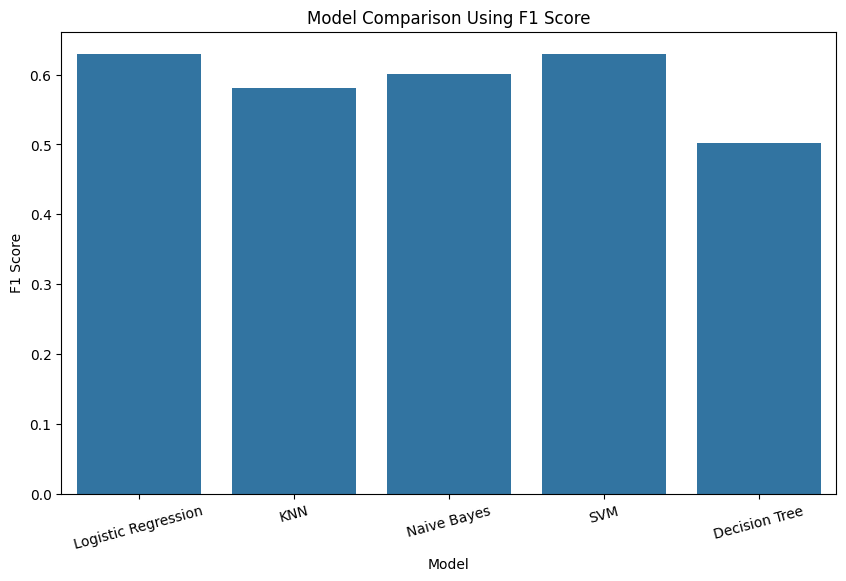

In [216]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.xticks(rotation=15)

plt.title("Model Comparison Using F1 Score")

plt.show()

# 6. Hyperparametre Tuning

# For K-NN

In [217]:
# Create Parameter Grid
knn_params = {
    'n_neighbors': [3,5,7,9,11,13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [218]:
# Create GridSearchCV
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [219]:
knn_grid.fit(
    X_train_fe_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [220]:
# Best Parameters
print(knn_grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}


In [221]:
# Best Score
print(knn_grid.best_score_)

0.5849165947656961


In [222]:
# Best KNN Model
best_knn = knn_grid.best_estimator_

In [223]:
knn_tuned_results = evaluate_model(
    best_knn,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7861579414374446
Precision: 0.5974025974025974
Recall: 0.6112956810631229
F1 Score: 0.6042692939244664
ROC-AUC: 0.8269167343721091

Confusion Matrix
[[702 124]
 [117 184]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       826
           1       0.60      0.61      0.60       301

    accuracy                           0.79      1127
   macro avg       0.73      0.73      0.73      1127
weighted avg       0.79      0.79      0.79      1127



# Hyperparametre Tuning For SVM

In [224]:
# Create Parameter Grid
svm_params = {

    'C': [0.1, 1, 10],

    'kernel': ['linear', 'rbf'],

    'gamma': ['scale', 'auto']
}

In [225]:
# Create GridSearch
svm_grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=svm_params,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

In [226]:
# Train
svm_grid.fit(
    X_train_fe_scaled,
    y_train
)

GridSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [227]:
# Best Parameters
print(svm_grid.best_params_)

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [228]:
# Best SVM Model
best_svm = svm_grid.best_estimator_

In [229]:
# Evaluate Tuned SVM
svm_tuned_results = evaluate_model(
    best_svm,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7959183673469388
Precision: 0.6381322957198443
Recall: 0.5448504983388704
F1 Score: 0.5878136200716846
ROC-AUC: 0.8303837893060261

Confusion Matrix
[[733  93]
 [137 164]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       826
           1       0.64      0.54      0.59       301

    accuracy                           0.80      1127
   macro avg       0.74      0.72      0.73      1127
weighted avg       0.79      0.80      0.79      1127



# Hyper Parametre Tuning for Decision Tree

In [230]:
# Parameter Grid
dt_params = {

    'max_depth': [3,5,7,10,None],

    'min_samples_split': [2,5,10],

    'min_samples_leaf': [1,2,4],

    'criterion': ['gini', 'entropy']
}

In [231]:
# Create GridSearch
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [232]:
# Train
dt_grid.fit(
    X_train_fe,
    y_train
)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [233]:
# Best Parameters
print(dt_grid.best_params_)

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [234]:
# Best Model
best_dt = dt_grid.best_estimator_

In [235]:
# Evaluate Tuned Decision Tree
dt_tuned_results = evaluate_model(
    best_dt,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

Accuracy: 0.7941437444543035
Precision: 0.610223642172524
Recall: 0.6345514950166113
F1 Score: 0.6221498371335505
ROC-AUC: 0.8389830508474575

Confusion Matrix
[[704 122]
 [110 191]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       826
           1       0.61      0.63      0.62       301

    accuracy                           0.79      1127
   macro avg       0.74      0.74      0.74      1127
weighted avg       0.80      0.79      0.80      1127



# Logistic Regression Tuning

In [236]:
# Parameter Grid
log_params = {

    'C': [0.01, 0.1, 1, 10],

    'solver': ['liblinear', 'lbfgs']
}

In [237]:
# Create GridSearch
log_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000
    ),
    param_grid=log_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [238]:
# Train
log_grid.fit(
    X_train_fe_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [239]:
# Best Parameters
print(log_grid.best_params_)

{'C': 0.01, 'solver': 'liblinear'}


In [240]:
# Best Model
best_log = log_grid.best_estimator_

In [241]:
# Evaluate Tuned Logistic Regression
log_tuned_results = evaluate_model(
    best_log,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.8047914818101154
Precision: 0.6483516483516484
Recall: 0.5880398671096345
F1 Score: 0.6167247386759582
ROC-AUC: 0.8420277847047373

Confusion Matrix
[[730  96]
 [124 177]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       826
           1       0.65      0.59      0.62       301

    accuracy                           0.80      1127
   macro avg       0.75      0.74      0.74      1127
weighted avg       0.80      0.80      0.80      1127



# Compare Tuned Models

In [242]:
# Create Results DataFrame
tuned_results_df = pd.DataFrame({

    'Model': [
        'Tuned Logistic Regression',
        'Tuned KNN',
        'Tuned SVM',
        'Tuned Decision Tree'
    ],

    'Accuracy': [
        log_tuned_results['Accuracy'],
        knn_tuned_results['Accuracy'],
        svm_tuned_results['Accuracy'],
        dt_tuned_results['Accuracy']
    ],

    'Precision': [
        log_tuned_results['Precision'],
        knn_tuned_results['Precision'],
        svm_tuned_results['Precision'],
        dt_tuned_results['Precision']
    ],

    'Recall': [
        log_tuned_results['Recall'],
        knn_tuned_results['Recall'],
        svm_tuned_results['Recall'],
        dt_tuned_results['Recall']
    ],

    'F1 Score': [
        log_tuned_results['F1'],
        knn_tuned_results['F1'],
        svm_tuned_results['F1'],
        dt_tuned_results['F1']
    ]
})

In [243]:
# View Results
tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,0.804791,0.648352,0.588040,0.616725
1,Tuned KNN,0.786158,0.597403,0.611296,0.604269
2,Tuned SVM,0.795918,0.638132,0.544850,0.587814
3,Tuned Decision Tree,0.794144,0.610224,0.634551,0.622150


In [244]:
# Sort by Best F1 Score
tuned_results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Tuned Decision Tree,0.794144,0.610224,0.634551,0.622150
0,Tuned Logistic Regression,0.804791,0.648352,0.588040,0.616725
1,Tuned KNN,0.786158,0.597403,0.611296,0.604269
2,Tuned SVM,0.795918,0.638132,0.544850,0.587814


# Visualize Tuned Models

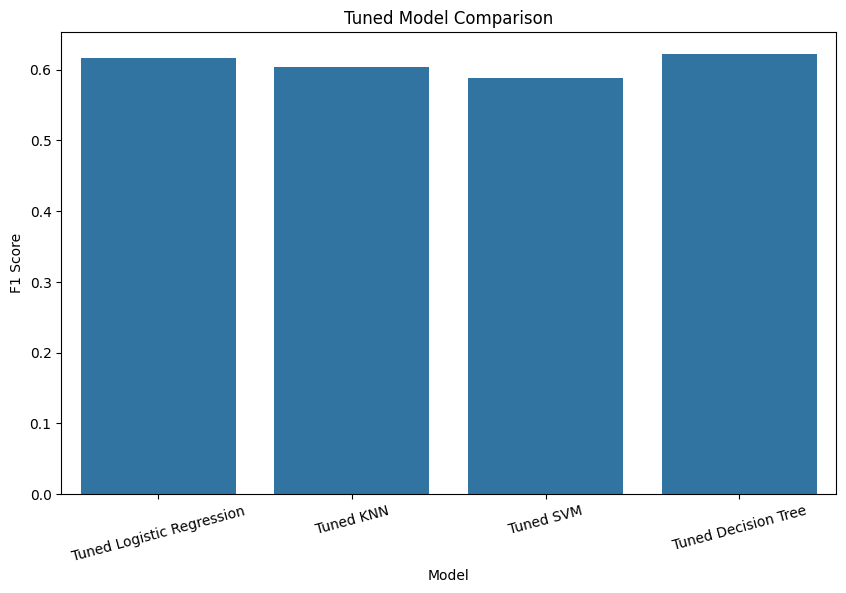

In [245]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=tuned_results_df
)

plt.xticks(rotation=15)

plt.title("Tuned Model Comparison")

plt.show()

# Step : 7 Conclusion

### Final Evaluation And Business Conclusion

In [246]:
# Business Insights

# Key findings from the analysis:

# - Customers with month-to-month contracts are more likely to churn.
# - Customers with high monthly charges have higher churn probability.
# - Customers with low tenure are at greater risk of leaving.
# - Fiber optic internet customers showed relatively high churn.
# - Long-term contracts improve customer retention.

# Final Conclusion

In [247]:
# This project successfully developed a machine learning pipeline for
# customer churn prediction.

# Among all evaluated models, Tuned Logistic Regression achieved
# the best overall performance based on F1 Score and Accuracy.

# The analysis revealed that contract type, tenure, monthly charges,
# and customer service usage are major churn indicators.

# The final model can help businesses:

# - Predict customer churn early
# - Improve customer retention
# - Reduce revenue loss
# - Design targeted retention campaigns